# AccelForge Test Notebook

This notebook verifies that AccelForge is installed in editable mode and working correctly.

In [49]:
# Test import
import accelforge
print("AccelForge imported successfully!")
print(f"AccelForge location: {accelforge.__file__}")

AccelForge imported successfully!
AccelForge location: /Users/mayarebholz/6.5930/accelforge/accelforge/__init__.py


In [50]:
from accelforge import Spec, examples
from pathlib import Path

In [51]:
def get_energy(result):
    """Get total energy in pJ."""
    return float(result.energy())


def get_cycles(result):
    """Get total latency in cycles."""
    return float(result.latency())


def get_component_energy(result, component):
    """Get energy for a specific component."""
    energy = result.energy(per_component=True)
    return float(energy.get(component, 0))

# GPT workload on TPU arch

In [52]:
# Load architecture and workload specifications
spec = Spec.from_yaml(
    examples.arches.tpu_v4i,
    examples.workloads.gpt3_175B
)


# Map the workload to the architecture
results = spec.map_workload_to_arch()


Getting energy, latency, and leak power for components running :   0%| | 0/10 
Getting energy, latency, and leak power for components running I:   0%| | 0/10
Getting energy, latency, and leak power for components running V:   0%| | 0/10
Getting energy, latency, and leak power for components running K:   0%| | 0/10
Getting energy, latency, and leak power for components running K:  30%|▎| 3/10
Getting energy, latency, and leak power for components running Q:  30%|▎| 3/10
Getting energy, latency, and leak power for components running QK:  30%|▎| 3/1
Getting energy, latency, and leak power for components running QK_softmax:  30
Getting energy, latency, and leak power for components running QK_softmax:  60
Getting energy, latency, and leak power for components running AV:  60%|▌| 6/1
Getting energy, latency, and leak power for components running Z:  60%|▌| 6/10
Getting energy, latency, and leak power for components running FFA:  60%|▌| 6/
Getting energy, latency, and leak power for compone

Einsum I has 2 pmapping jobs:
	0	[I_in in MainMemory] T-b  T-d  T-m  [I in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
	1	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
Einsum V has 92 pmapping jobs:
	0	[WV in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V in GlobalBuffer] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I in LocalBuffer] T-e  T-h  [V in LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	1	[WV in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V in GlobalBuffer] T-b  T-e  T-h  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [V in LocalBuffer] T-d  [I in LocalBuffer] T-e  T-h  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	2	[WV in MainMemory] T-b  T-m  [I in GlobalBuffer] T-b  T-e  T-h  T-m  [V in GlobalBuffer] T-d  T-e  T-h  [WV in GlobalBuffer] T-b  T-m  S


Generating pmappings:   1%|▏                  | 6/858 [00:10<14:58,  1.06s/it]/Users/mayarebholz/6.5930/accelforge_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(

Generating pmappings:   1%|▏                  | 7/858 [00:11<14:31,  1.02s/it]/Users/mayarebholz/6.5930/accelforge_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(

Generating pmappings:   2%|▍                 | 19/858 [00:53<57:35,  4.12s/it]/Users/mayarebholz/6.5930/accelforge_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caus

Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal



Dirty pruning pmappings: 100%|█████████████| 569/569 [00:01<00:00, 359.07it/s]


...


Dirty pruning pmappings: 100%|█████████████| 569/569 [00:00<00:00, 624.29it/s]


Dirty joining uses 99.96% of the pmappings
Filtered 202382 -> 125384 (61.95% kept) pmappings



Joining pmappings for I <--> V (2/10): 100%|█| 48/48 [00:00<00:00, 230.95it/s]

Joining pmappings for V <--> K (3/10):   7%|▏ | 9/129 [00:00<00:01, 89.43it/s]
Joining pmappings for V <--> K (3/10):  24%|▏| 31/129 [00:00<00:00, 162.55it/s
Joining pmappings for V <--> K (3/10):  38%|▍| 49/129 [00:00<00:00, 165.52it/s
Joining pmappings for V <--> K (3/10): 100%|█| 129/129 [00:00<00:00, 244.99it/

Grouping pmappings: 100%|████████████████████| 23/23 [00:00<00:00, 243.49it/s]

Joining pmappings for K <--> Q (4/10):   7%|▏ | 8/111 [00:00<00:01, 71.01it/s]
Joining pmappings for K <--> Q (4/10):  28%|▎| 31/111 [00:00<00:00, 156.38it/s
Joining pmappings for K <--> Q (4/10):  44%|▍| 49/111 [00:00<00:00, 155.46it/s
Joining pmappings for K <--> Q (4/10): 100%|█| 111/111 [00:00<00:00, 225.84it/

Grouping pmappings: 100%|████████████████████| 24/24 [00:00<00:00, 183.20it/s]

Joining pmappings for Q <--> QK (5/10):   5%| | 9/185 [00:00<00:02, 86.71it/s]
Joining pmappings for Q <--> QK (5/10):  12%| 

Dirty joining mapping(s) valid & optimal! Returning...


/Users/mayarebholz/6.5930/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


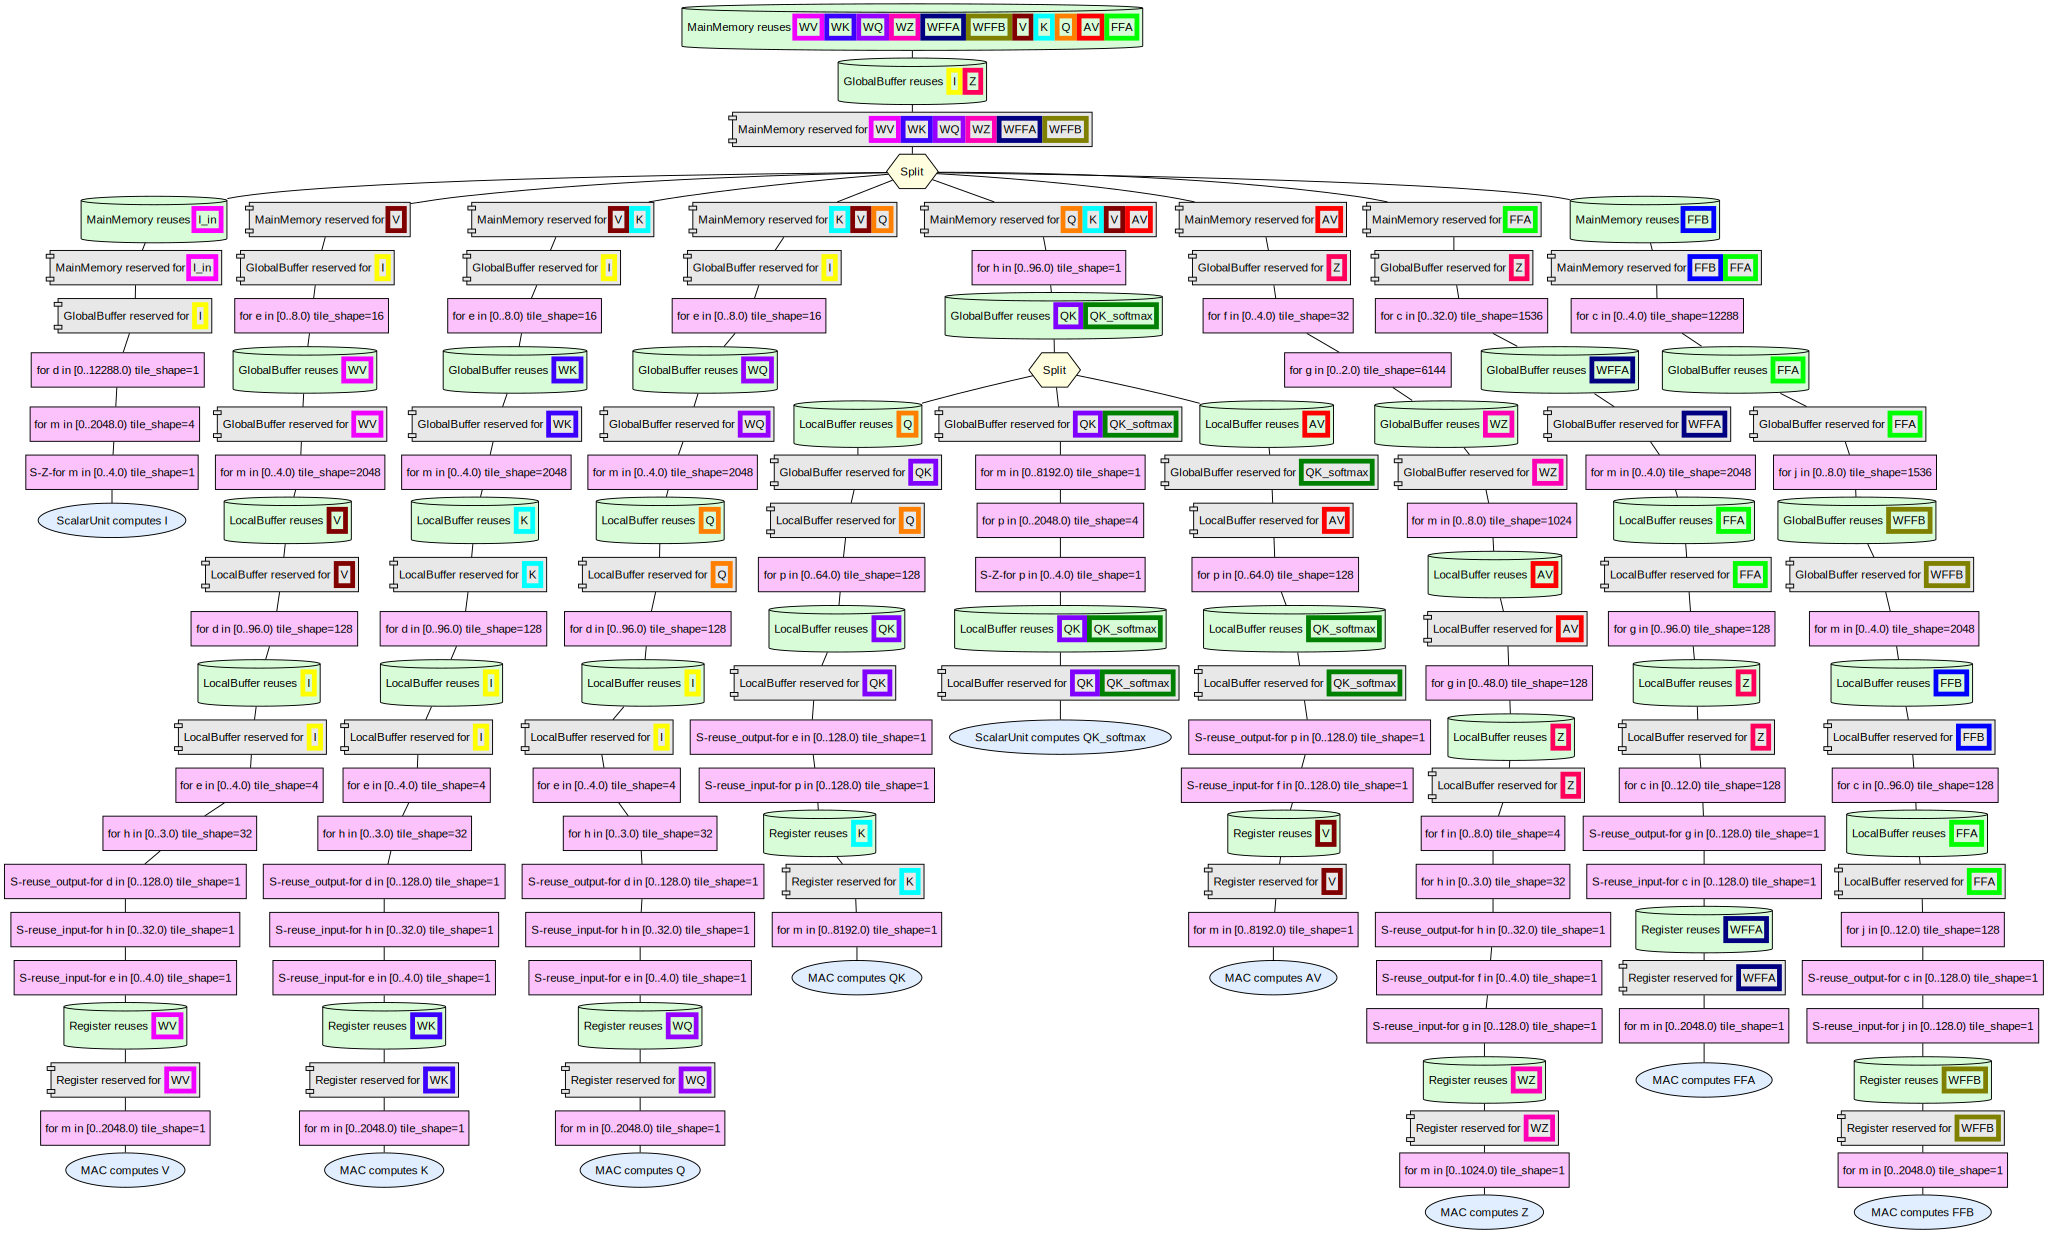

In [53]:
results

In [54]:
# Analyze the results for data dependent
print(get_energy(results))

print(get_cycles(results))

print("MainMemory: ", get_component_energy(results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(results, 'GlobalBuffer'))
print("LocalBuffer: ", get_component_energy(results, 'LocalBuffer'))
print("ProcessingElement: ", get_component_energy(results, 'ProcessingElement'))
print("Register: ", get_component_energy(results, 'Register'))
print("ScalarUnit: ", get_component_energy(results, 'ScalarUnit'))
print("MAC: ", get_component_energy(results, 'MAC'))

3.2830834839383325
0.9708690657862462
MainMemory:  0.24343605991452932
GlobalBuffer:  0.743845404474996
LocalBuffer:  0.910417368434632
ProcessingElement:  0.0
Register:  0.0
ScalarUnit:  0.0
MAC:  1.3853846509977599


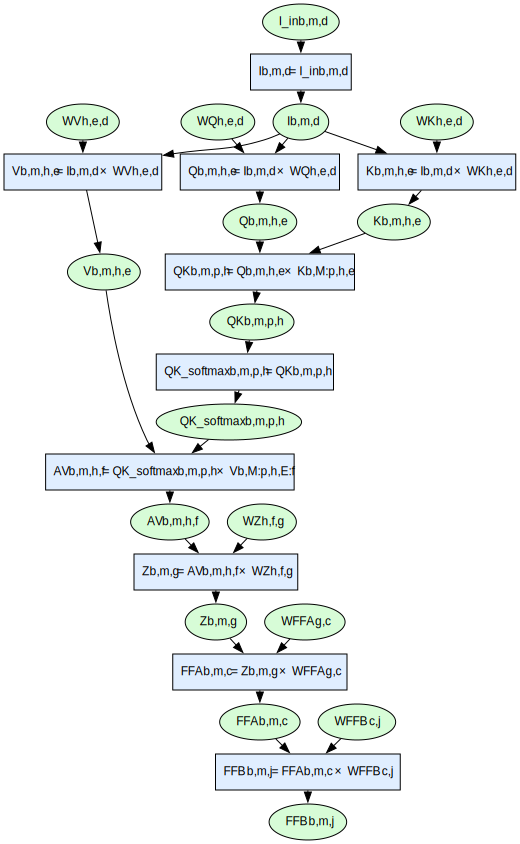

In [55]:
spec.workload

# Parallel Workload (All I_in)

In [56]:
# Load architecture and workload specifications
spec = Spec.from_yaml(
    examples.arches.tpu_v4i,
    "../workloads/gpt3_175B_all_I_in.yaml"
)


# Map the workload to the architecture
results = spec.map_workload_to_arch()


Getting energy, latency, and leak power for components running :   0%| | 0/10 
Getting energy, latency, and leak power for components running I:   0%| | 0/10
Getting energy, latency, and leak power for components running V:   0%| | 0/10
Getting energy, latency, and leak power for components running V:  20%|▏| 2/10
Getting energy, latency, and leak power for components running K:  20%|▏| 2/10
Getting energy, latency, and leak power for components running Q:  20%|▏| 2/10
Getting energy, latency, and leak power for components running QK:  20%|▏| 2/1
Getting energy, latency, and leak power for components running QK:  50%|▌| 5/1
Getting energy, latency, and leak power for components running QK_softmax:  50
Getting energy, latency, and leak power for components running AV:  50%|▌| 5/1
Getting energy, latency, and leak power for components running Z:  50%|▌| 5/10
Getting energy, latency, and leak power for components running Z:  80%|▊| 8/10
Getting energy, latency, and leak power for compone

Einsum I has 1 pmapping job:
	0	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
Einsum V has 32 pmapping jobs:
	0	[WV in MainMemory] [V in MainMemory] [I_in in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I_in in LocalBuffer] T-e  T-h  [V in LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	1	[WV in MainMemory] [V in MainMemory] [I_in in MainMemory] T-b  T-e  T-h  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [V in LocalBuffer] T-d  [I_in in LocalBuffer] T-e  T-h  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	2	[WV in MainMemory] [V in MainMemory] [I_in in MainMemory] T-b  T-d  T-m  [I_in in GlobalBuffer] S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I_in in LocalBuffer] T-e  T-h  [V in LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	3	[WV in MainMemory] [V in M


Grouping pmappings for Q: 100%|█████████████████| 1/1 [00:00<00:00, 11.05it/s]

Grouping pmappings for QK: 100%|██████████████| 22/22 [00:03<00:00,  7.01it/s]

Grouping pmappings for FFB: 100%|███████████████| 1/1 [00:00<00:00,  9.59it/s]

Compressing pmappings: 100%|██████████████████| 10/10 [00:00<00:00, 30.97it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal



Dirty pruning pmappings: 100%|███████████████| 38/38 [00:00<00:00, 370.58it/s]


...


Dirty pruning pmappings: 100%|███████████████| 38/38 [00:00<00:00, 550.09it/s]


Dirty joining uses 99.98% of the pmappings
Filtered 18045 -> 4291 (23.78% kept) pmappings


Joining pmappings for K <--> Q (4/10): 100%|████| 1/1 [00:00<00:00, 76.50it/s]

Joining pmappings for Q <--> QK (5/10): 100%|█| 21/21 [00:00<00:00, 216.30it/s

Joining pmappings for QK <--> QK_softmax (6/10):   0%| | 0/21 [00:00<?, ?it/s]
Joining pmappings for QK <--> QK_softmax (6/10): 100%|█| 21/21 [00:00<00:00, 2
Grouping pmappings: 100%|███████████████████████| 1/1 [00:00<00:00, 30.05it/s]
Joining pmappings for QK_softmax <--> AV (7/10): 100%|█| 1/1 [00:00<00:00, 64.
Joining pmappings for Z <--> FFA (9/10): 100%|██| 1/1 [00:00<00:00, 64.10it/s]
Joining pmappings for FFA <--> FFB (10/10): 100%|█| 1/1 [00:00<00:00, 63.69it/
Final consolidate: 100%|██████████████████████| 1/1 [00:00<00:00, 2142.14it/s]
/Users/mayarebholz/6.5930/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using

Dirty joining mapping(s) valid & optimal! Returning...


/Users/mayarebholz/6.5930/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


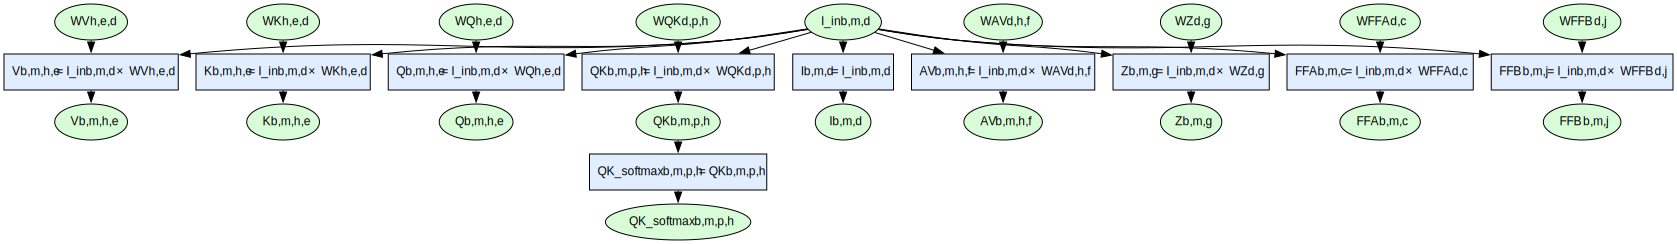

In [57]:
spec.workload

In [58]:
# Analyze the results for parallel
print(get_energy(results))

print(get_cycles(results))

print("MainMemory: ", get_component_energy(results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(results, 'GlobalBuffer'))
print("LocalBuffer: ", get_component_energy(results, 'LocalBuffer'))
print("ProcessingElement: ", get_component_energy(results, 'ProcessingElement'))
print("Register: ", get_component_energy(results, 'Register'))
print("ScalarUnit: ", get_component_energy(results, 'ScalarUnit'))
print("MAC: ", get_component_energy(results, 'MAC'))

15.515468935351535
5.3329453929909505
MainMemory:  1.0926316203549504
GlobalBuffer:  2.0131693184375763
LocalBuffer:  4.720783183521438
ProcessingElement:  0.0
Register:  0.0
ScalarUnit:  0.0
MAC:  7.688884813037567


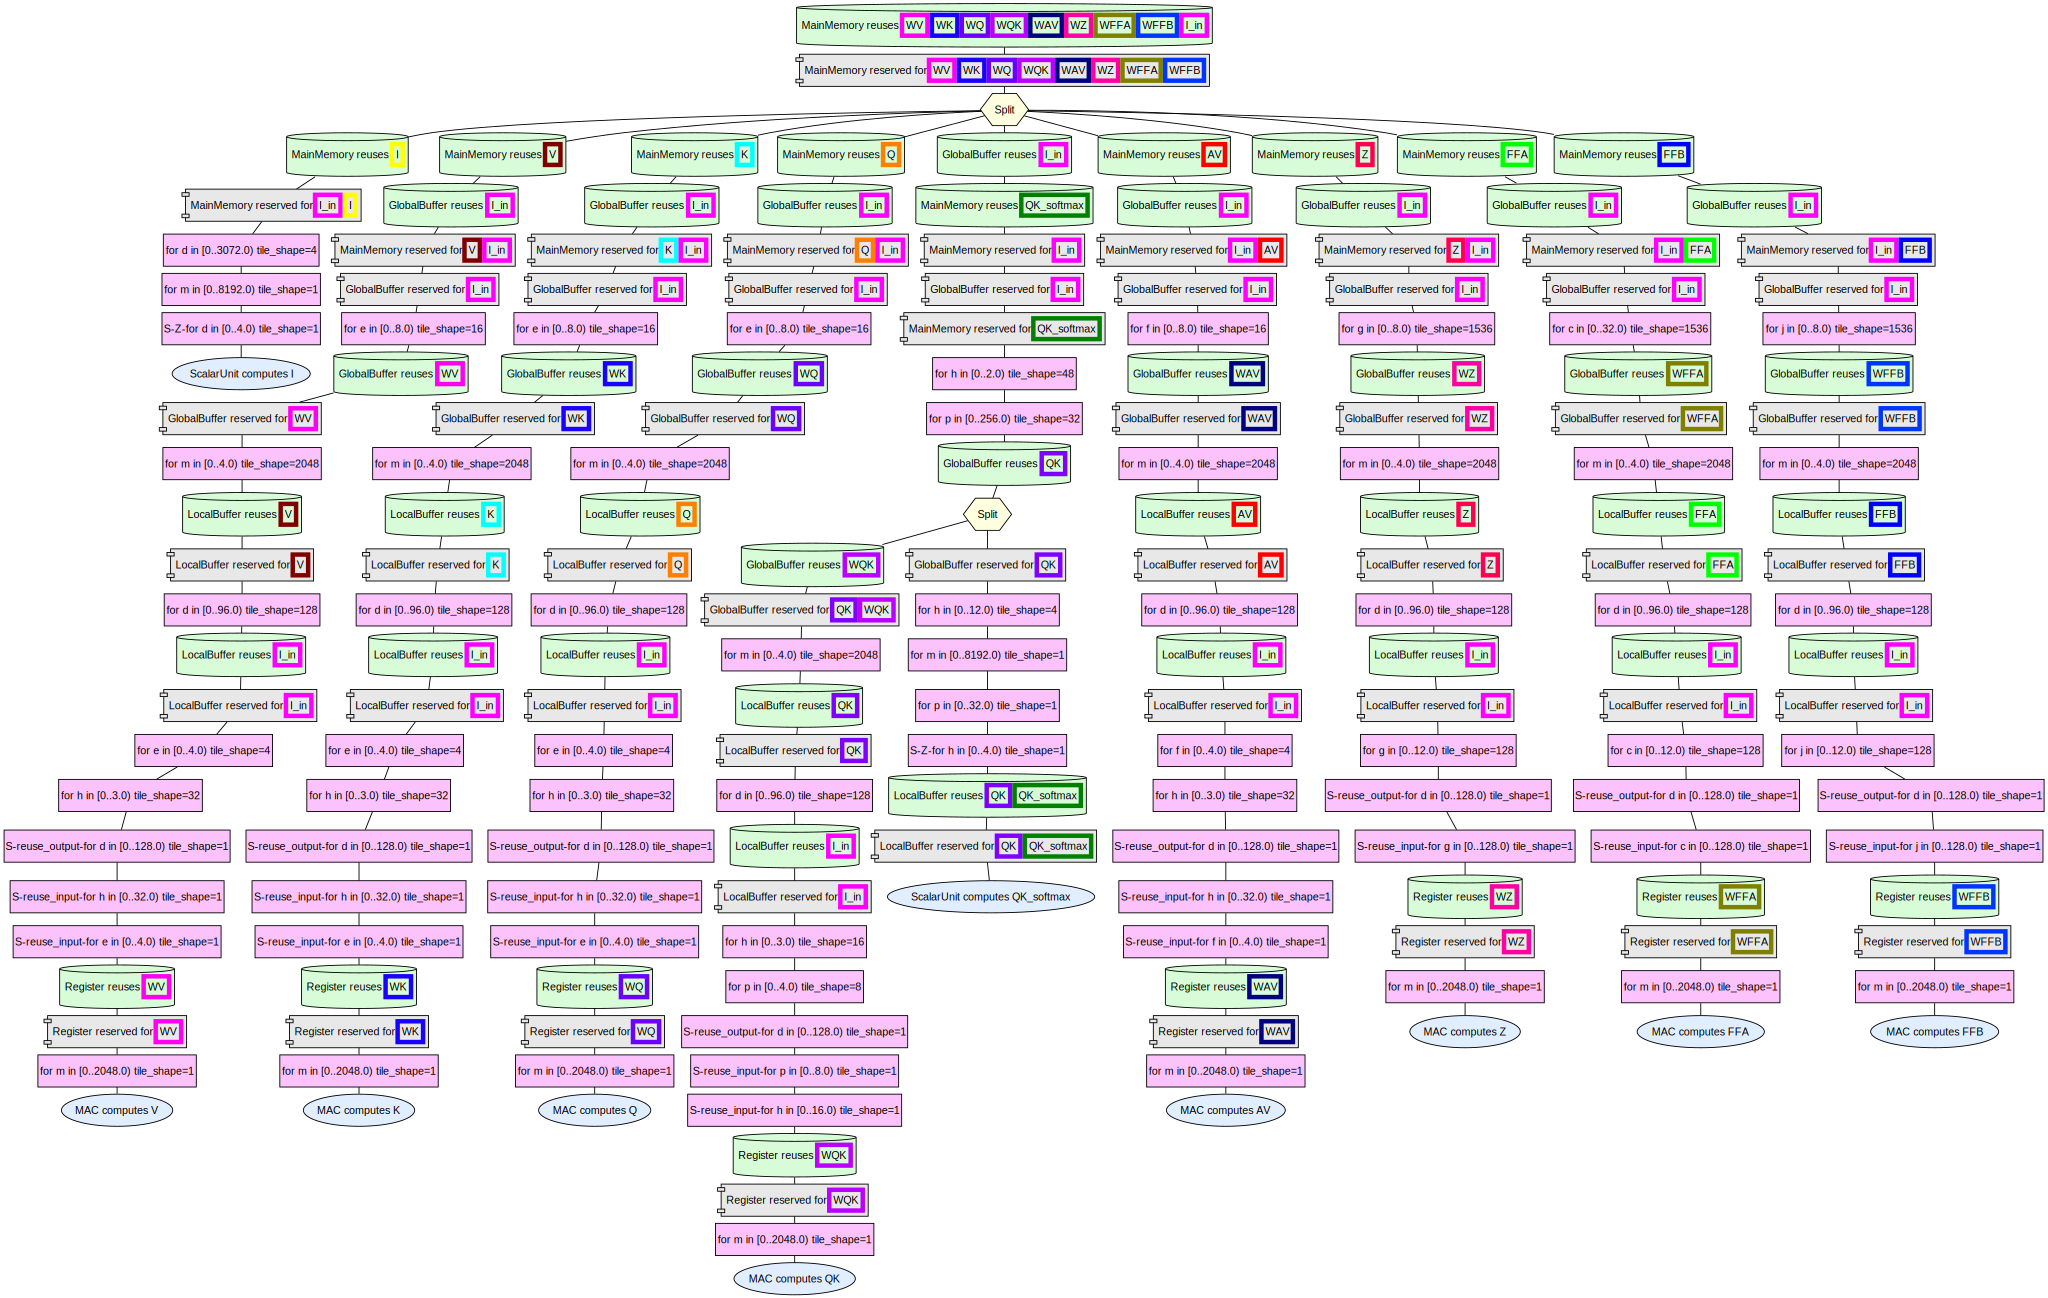

In [59]:
results

# Parallel Workload (All renamed)

In [61]:
# Load architecture and workload specifications
spec_all_renamed = Spec.from_yaml(
    examples.arches.tpu_v4i,
    "../workloads/gpt3_175B_all_renamed.yaml"
)


# Map the workload to the architecture
results_all_renamed = spec_all_renamed.map_workload_to_arch()


Getting energy, latency, and leak power for components running :   0%| | 0/10 
Getting energy, latency, and leak power for components running I:   0%| | 0/10
Getting energy, latency, and leak power for components running I:  10%| | 1/10
Getting energy, latency, and leak power for components running V:  10%| | 1/10
Getting energy, latency, and leak power for components running K:  10%| | 1/10
Getting energy, latency, and leak power for components running K:  30%|▎| 3/10
Getting energy, latency, and leak power for components running Q:  30%|▎| 3/10
Getting energy, latency, and leak power for components running QK:  30%|▎| 3/1
Getting energy, latency, and leak power for components running QK:  50%|▌| 5/1
Getting energy, latency, and leak power for components running QK_softmax:  50
Getting energy, latency, and leak power for components running AV:  50%|▌| 5/1
Getting energy, latency, and leak power for components running AV:  70%|▋| 7/1
Getting energy, latency, and leak power for compone

Einsum I has 1 pmapping job:
	0	[I_in in MainMemory] [I in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-d  S-Z-b  ScalarUnit computes I
Einsum V has 32 pmapping jobs:
	0	[WV in MainMemory] [V in MainMemory] [I1 in MainMemory] T-b  T-d  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I1 in LocalBuffer] T-e  T-h  [V in LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	1	[WV in MainMemory] [V in MainMemory] [I1 in MainMemory] T-b  T-e  T-h  T-m  S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [V in LocalBuffer] T-d  [I1 in LocalBuffer] T-e  T-h  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	2	[WV in MainMemory] [V in MainMemory] [I1 in MainMemory] T-b  T-d  T-m  [I1 in GlobalBuffer] S-Z-m  S-Z-h  S-Z-e  S-Z-d  S-Z-b  [I1 in LocalBuffer] T-e  T-h  [V in LocalBuffer] T-d  S-reuse_output-d  S-reuse_input-h  S-reuse_input-e  [WV in Register] T-b  T-m  MAC computes V
	3	[WV in MainMemory] [V in MainMemory] [I1

Generating pmappings:   3%|▍                  | 7/267 [00:25<12:26,  2.87s/it]/Users/mayarebholz/6.5930/accelforge_env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Compressing pmappings: 100%|██████████████████| 10/10 [00:00<00:00, 85.70it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|███████████████| 10/10 [00:00<00:00, 375.87it/s]


...

Dirty pruning pmappings: 100%|███████████████| 10/10 [00:00<00:00, 190.80it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 10 -> 10 (100.00% kept) pmappings


Joining pmappings for Q <--> QK (5/10): 100%|██| 1/1 [00:00<00:00, 123.87it/s]
Joining pmappings for QK <--> QK_softmax (6/10): 100%|█| 1/1 [00:00<00:00, 105
Joining pmappings for QK_softmax <--> AV (7/10): 100%|█| 1/1 [00:00<00:00, 80.
Joining pmappings for Z <--> FFA (9/10): 100%|██| 1/1 [00:00<00:00, 96.55it/s]
Joining pmappings for FFA <--> FFB (10/10): 100%|█| 1/1 [00:00<00:00, 95.90it/
Final consolidate: 100%|██████████████████████| 1/1 [00:00<00:00, 1818.08it/s]
/Users/mayarebholz/6.5930/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


Dirty joining mapping(s) valid & optimal! Returning...


/Users/mayarebholz/6.5930/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:352: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


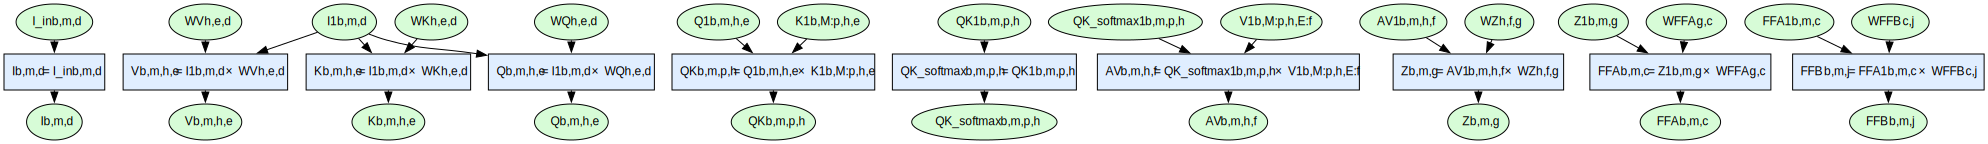

In [62]:
spec_all_renamed.workload

In [63]:
# Analyze the results for all renamed
print(get_energy(results_all_renamed))

print(get_cycles(results_all_renamed))

print("MainMemory: ", get_component_energy(results_all_renamed, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(results_all_renamed, 'GlobalBuffer'))
print("LocalBuffer: ", get_component_energy(results_all_renamed, 'LocalBuffer'))
print("ProcessingElement: ", get_component_energy(results_all_renamed, 'ProcessingElement'))
print("Register: ", get_component_energy(results_all_renamed, 'Register'))
print("ScalarUnit: ", get_component_energy(results_all_renamed, 'ScalarUnit'))
print("MAC: ", get_component_energy(results_all_renamed, 'MAC'))

4.311284111359361
0.9798705219873227
MainMemory:  1.7097137034870684
GlobalBuffer:  0.3056620900752023
LocalBuffer:  0.9105236667993308
ProcessingElement:  0.0
Register:  0.0
ScalarUnit:  0.0
MAC:  1.3853846509977599


In [ ]:
results_all_renamed